# Day 8: Foundation-model embeddings with a Bayesian head

Regime Lab (Zetheta Algorithms internship, Task 1A), Section D2, Day 8.

**What this is, and is not.** The pretrained Chronos and TimesFM
checkpoints cannot be downloaded from this sandbox (Hugging Face returns
`403 host_not_allowed`, and torch is broken here). So two small
architecture-level re-implementations were built in TensorFlow and
**pretrained on synthetic data**, as instructed:

- a *Chronos-style* model: mean-absolute scaling, uniform binning into a
  token vocabulary, a causal transformer, next-token cross-entropy;
- a *TimesFM-style* model: patches of 12 days, a causal transformer over
  patches, next-patch quantile (pinball) forecasts.

They have about 0.1M parameters each. **Nothing here is Amazon's or
Google's model, and nothing here says whether a real pretrained
foundation model transfers to Indian equities.** It tests the hybrid
pipeline (embedding, then Bayesian head) and whether pretraining on
generic series helps a regime head at all.

**Protocol (continuing Day 7).** Windows are the 252 daily returns ending
on each date. Heads are trained on Day 7's HMM regime labels (Section
A4.6) and scored on the same chronological test window (the last 702
days). Because the panel is synthetic, the generator's *true* regimes are
available for scoring and were never shown to any model. The head is the
same variational (`DenseFlipout`) network for every input, with a fixed
gradient-step budget, so differences come from the input representation.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from src.data.loader import DataConfig, load_market_data
from src.utils.plot_style import new_figure, PALETTE

pd.set_option('display.precision', 3); pd.set_option('display.width', 220)
A = '../artifacts_data/day8'
ARMS = ['engineered', 'chronos', 'patch', 'patch_noswitch', 'chronos_rand', 'patch_rand', 'raw_window', 'patch_quantiles']

In [2]:
from src.models.foundation import chronos_style as cs, patch_model as pmod
lm, _ = cs.build_mini_chronos(); fm, _ = pmod.build_mini_timesfm()
print(f"Chronos-style parameters: {lm.count_params():,} | TimesFM-style parameters: {fm.count_params():,}")
print(f"Chronos-style: vocab {cs.MeanScaleTokenizer().vocab_size} tokens; TimesFM-style: 252 days = 21 patches of 12")

I0000 00:00:1790579514.102339    1027 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790579514.102868    1027 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790579514.141798    1027 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790579515.104592    1027 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790579515.104890    1027 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1790579515.226521    1027 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Chronos-style parameters: 116,482 | TimesFM-style parameters: 105,060
Chronos-style: vocab 258 tokens; TimesFM-style: 252 days = 21 patches of 12


## 1. Did pretraining learn anything?

Pretraining used `src/models/foundation/corpus.py`: series drawn on the
fly from nine generic families with randomised parameters and scales
(AR, random walk with drift, GARCH, **Markov regime switching**, Student-t,
seasonal, trend, jumps, mean-reverting level shifts). The regime-switching
family is the same *kind* of process as the project's synthetic market,
with independently randomised parameters. That overlap could make transfer
look friendlier than it should, so a control was run with that family
**excluded** (Section 4).

A model with no temporal knowledge is the bar to clear, so each loss is
compared with a static baseline: the entropy of the best fixed token
distribution (Chronos-style) and pooled empirical quantiles (TimesFM-style),
both on freshly drawn held-out series.

chronos: 3000 steps, 863s wall, last logged loss 4.1985
patch: 12000 steps, 377s wall, last logged loss 0.2176
patch_noswitch: 12000 steps, 360s wall, last logged loss 0.2165


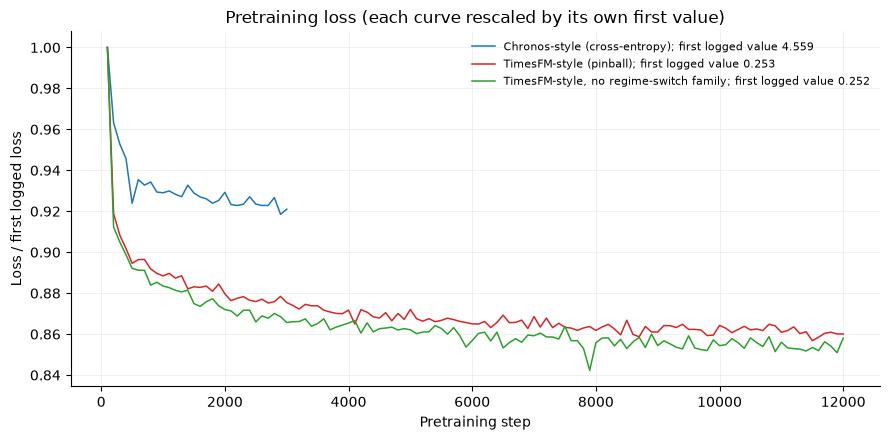

In [3]:
fig, ax = new_figure()
for tag, label, c in [('chronos', 'Chronos-style (cross-entropy)', PALETTE[0]),
                      ('patch', 'TimesFM-style (pinball)', PALETTE[1]),
                      ('patch_noswitch', 'TimesFM-style, no regime-switch family', PALETTE[2])]:
    h = np.array(json.load(open(f'{A}/{tag}_state.json'))['loss_history'])
    ax.plot(h[:, 0], h[:, 1] / h[0, 1], label=f"{label}; first logged value {h[0,1]:.3f}", color=c)
ax.set_xlabel('Pretraining step'); ax.set_ylabel('Loss / first logged loss')
ax.set_title('Pretraining loss (each curve rescaled by its own first value)')
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig('../docs/artifacts/day8_pretraining_loss.png', dpi=110)
for tag in ['chronos', 'patch', 'patch_noswitch']:
    s = json.load(open(f'{A}/{tag}_state.json'))
    print(f"{tag}: {s['steps']} steps, {s['wall_seconds']:.0f}s wall, last logged loss {s['loss_history'][-1][1]:.4f}")

In [4]:
ev = json.load(open(f'{A}/pretrain_eval.json'))
rows = []
for k, v in ev.items():
    rows.append({'held-out set': k,
                 'CE trained': v['chronos_ce_trained'], 'CE static': v['chronos_ce_static_unigram'],
                 'CE gain (nats)': v['chronos_ce_static_unigram'] - v['chronos_ce_trained'],
                 'pinball trained': v['patch_pinball_trained'], 'pinball static': v['patch_pinball_static'],
                 'pinball gain %': 100 * (v['patch_pinball_static'] - v['patch_pinball_trained']) / v['patch_pinball_static'],
                 'median-forecast MAE / context-mean MAE': v['median_mae_over_context_mean_mae_median_of_windows'],
                 '10-90% coverage': v['interval_80_coverage']})
pre = pd.DataFrame(rows).set_index('held-out set')
pre

,CE trained,CE static,CE gain (nats),pinball trained,pinball static,pinball gain %,median-forecast MAE / context-mean MAE,10-90% coverage
held-out set,,,,,,,,
ar,4.334,4.414,0.080,0.245,0.251,2.479,1.001,0.787
rw_drift,4.427,4.415,-0.013,0.249,0.251,0.626,1.005,0.793
garch,4.414,4.431,0.017,0.244,0.248,1.666,1.005,0.768
regime_switch,4.370,4.443,0.072,0.240,0.247,3.052,0.997,0.789
student_t,4.429,4.438,0.010,0.241,0.243,1.063,1.004,0.810
seasonal,4.186,4.364,0.178,0.188,0.251,25.143,0.825,0.751
trend,3.905,4.371,0.466,0.162,0.245,33.913,0.955,0.360
jumps,4.410,4.379,-0.031,0.223,0.227,1.741,1.001,0.803
ou_level_shift,3.365,4.380,1.015,0.181,0.248,27.298,0.946,0.557


**Read this table carefully.** Pretraining learned real structure, but
only in some families. On trend, seasonal and level-shift series the gains
over the static baselines are large (roughly 25 to 34% in pinball loss).
On the return-like families (AR, random walk with drift, GARCH,
regime-switching, Student-t, jumps) the gains are small or absent: within a
few percent in pinball loss, and close to zero or slightly negative in
cross-entropy for several of them. **On the project's own returns the
Chronos-style cross-entropy equals the static baseline, and the median
forecast is no closer to the target than a context mean** (ratio about 1.0).
The 10-90% interval coverage is close to its 0.80 target there.

So these are not useful forecasters of return-like data. Whatever the
embeddings carry about regimes (Section 3) does not come from forecasting
skill on returns.

## 2. Embeddings and protocol

`scripts/run_day8_embed.py` produced mean-pooled hidden states (64-d) for
every date in Day 7's label set, from the trained and from an **untrained
copy of the same architecture** (fixed random initialisation). The
untrained copy is the control that separates "pretraining helps" from
"any transformer's random features help". Both models normalise scale away
(Chronos-style by mean absolute value, TimesFM-style by z-scoring), so
their embeddings do not carry the window's volatility *level*.

In [5]:
E = np.load(f'{A}/embeddings.npz')
print({k: E[k].shape for k in E.files if k != 'dates'})
n_all = len(E['dates']); n_train = int(0.8 * n_all)
dates = pd.to_datetime(E['dates'])
truth = load_market_data(DataConfig(backend='synthetic', n_years=15.0, seed=7))['regime_path']['regime'].reindex(dates[n_train:])
true_stress = truth.isin(['risk_off', 'post_shock']).values.astype(int)
runs, cur = [], 0
for v in true_stress:
    if v: cur += 1
    elif cur: runs.append(cur); cur = 0
if cur: runs.append(cur)
print(f"windows: {n_all} | training window: first {n_train} | test window: {dates[n_train].date()} to {dates[-1].date()} ({n_all-n_train} days)")
print(f"true Risk-Off/Post-Shock days in the test window: {true_stress.sum()}, in {len(runs)} contiguous episode(s) of {runs} days")

{'chronos': (3508, 64), 'chronos_rand': (3508, 64), 'patch': (3508, 64), 'patch_rand': (3508, 64), 'patch_quantiles': (3508, 36), 'raw': (3508, 252)}


windows: 3508 | training window: first 2806 | test window: 2022-10-20 to 2025-06-27 (702 days)
true Risk-Off/Post-Shock days in the test window: 146, in 2 contiguous episode(s) of [62, 84] days


Two limits to keep in view. The test window holds only **two** true
stress episodes, so any AUROC below rests on two events, not 146 days. And
each arm uses **3 random training subsets** per size, so the curves are
noisy; error bars are one standard deviation across those 3.

## 3. Sample efficiency

{'chronos': 21, 'chronos_rand': 21, 'engineered': 21, 'patch': 21, 'patch_noswitch': 21, 'patch_quantiles': 21, 'patch_rand': 21, 'raw_window': 21}


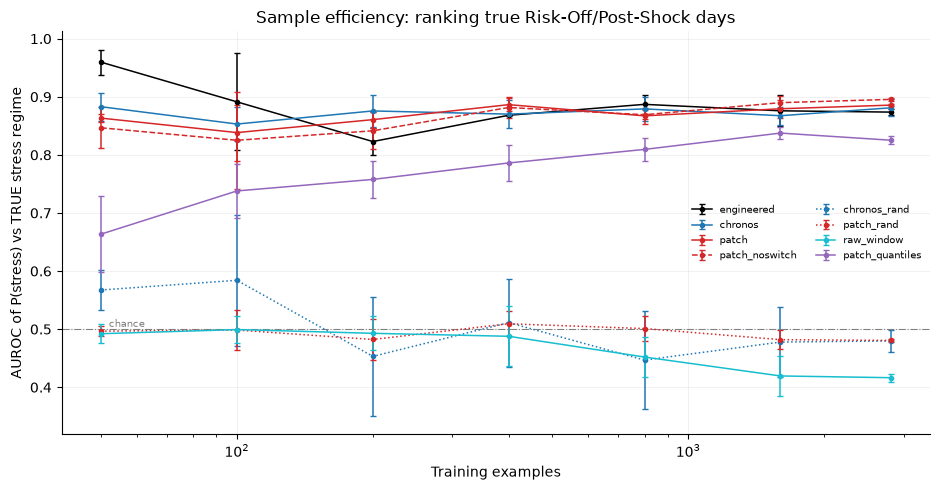

In [6]:
rows = []
for m in ARMS:
    for k, v in json.load(open(f'{A}/sample_eff_{m}.json')).items():
        rows.append(dict(method=m, **v))
df = pd.DataFrame(rows)
print(df.groupby('method').size().to_dict())

def curve_plot(metric, ylabel, title, fname, ref=None):
    fig, ax = new_figure(); fig.set_size_inches(9.5, 5)
    g = df.groupby(['method', 'n'])[metric].agg(['mean', 'std']).reset_index()
    style = {'engineered': ('black', '-'), 'chronos': (PALETTE[0], '-'), 'patch': (PALETTE[1], '-'),
             'patch_noswitch': (PALETTE[1], '--'), 'chronos_rand': (PALETTE[0], ':'), 'patch_rand': (PALETTE[1], ':'),
             'raw_window': (PALETTE[5], '-'), 'patch_quantiles': (PALETTE[3], '-')}
    for m in ARMS:
        s = g[g.method == m]; c, ls = style[m]
        ax.errorbar(s['n'], s['mean'], yerr=s['std'], color=c, linestyle=ls, marker='o', markersize=3, linewidth=1.1, capsize=2, label=m)
    if ref is not None:
        for val, lab in ref: ax.axhline(val, color='grey', linewidth=0.8, linestyle='-.'); ax.text(52, val + 0.004, lab, fontsize=7, color='grey')
    ax.set_xscale('log'); ax.set_xlabel('Training examples'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=7, ncol=2); fig.tight_layout(); fig.savefig(fname, dpi=110)

curve_plot('auroc_true_stress', 'AUROC of P(stress) vs TRUE stress regime',
           'Sample efficiency: ranking true Risk-Off/Post-Shock days', '../docs/artifacts/day8_sample_efficiency_true_stress.png',
           ref=[(0.5, 'chance')])

In [7]:
piv = df.pivot_table(index='n', columns='method', values='auroc_true_stress', aggfunc='mean')[ARMS]
print("AUROC vs TRUE stress, mean over 3 subsets:"); piv.round(3)

AUROC vs TRUE stress, mean over 3 subsets:


method,engineered,chronos,patch,patch_noswitch,chronos_rand,patch_rand,raw_window,patch_quantiles
n,,,,,,,,
50,0.960,0.883,0.863,0.847,0.567,0.497,0.492,0.664
100,0.891,0.853,0.838,0.825,0.584,0.498,0.499,0.738
200,0.823,0.876,0.861,0.841,0.453,0.482,0.493,0.758
400,0.868,0.870,0.886,0.882,0.511,0.509,0.488,0.786
800,0.887,0.879,0.867,0.869,0.447,0.501,0.452,0.809
1600,0.876,0.867,0.879,0.890,0.478,0.482,0.419,0.838
2806,0.874,0.881,0.886,0.896,0.480,0.481,0.416,0.825


Mean over training sizes n >= 200 (the curves are close to flat there):


,auroc_true_stress,auroc_hmm_stress,balanced_accuracy,nll_minus_prior,accuracy
method,,,,,
engineered,0.866,0.945,0.299,-0.064,0.869
chronos,0.875,0.720,0.200,0.320,0.856
patch,0.876,0.676,0.221,0.292,0.808
patch_noswitch,0.876,0.677,0.215,0.279,0.811
chronos_rand,0.474,0.335,0.199,0.714,0.852
patch_rand,0.491,0.465,0.199,0.385,0.851
raw_window,0.454,0.522,0.199,0.453,0.854
patch_quantiles,0.803,0.630,0.199,0.052,0.845


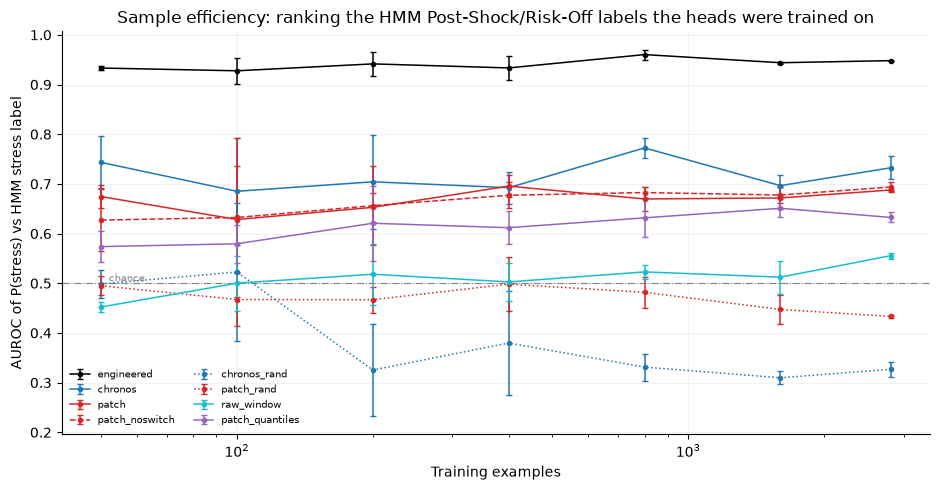

In [8]:
curve_plot('auroc_hmm_stress', 'AUROC of P(stress) vs HMM stress label',
           'Sample efficiency: ranking the HMM Post-Shock/Risk-Off labels the heads were trained on',
           '../docs/artifacts/day8_sample_efficiency_hmm_stress.png', ref=[(0.5, 'chance')])
big = df[df.n >= 200].groupby('method')[['auroc_true_stress', 'auroc_hmm_stress', 'balanced_accuracy', 'nll_minus_prior', 'accuracy']].mean().loc[ARMS]
print("Mean over training sizes n >= 200 (the curves are close to flat there):"); big.round(3)

**What the curves show.**

- **Pretraining matters for these architectures.** The pretrained
  Chronos-style and TimesFM-style embeddings rank true stress days with
  AUROC around 0.87 to 0.88, while the *same architectures untrained* sit at
  chance. The raw 252-return window (no pretraining, no engineering) is also
  at or below chance.
- **They are sample-efficient in the sense of being nearly flat**: AUROC is
  already about 0.85 to 0.88 at 50 training examples. The Chronos-style curve
  stays flat; the two TimesFM-style curves rise by roughly 0.02 to 0.05.
- **But that does not beat the from-scratch route.** The engineered-feature
  arm reaches about the same level at large n, and at the smallest sizes it is
  *higher* (n=50 and n=100 in the table), though noisy. The curves cross; no
  representation dominates. The task's expected result, hybrid ahead of
  scratch on sample efficiency, is **not supported** here.
- **Against the labels the heads were actually trained on (HMM stress), the
  embeddings are much worse** than engineered features (second figure and the
  table above). The embeddings are scale-free, and the HMM states differ in
  volatility *level*, which they cannot see.
- **Calibration and argmax metrics are poor for the embedding arms.** Balanced
  accuracy sits at 0.20 to 0.22 (essentially always predicting Risk-On) against
  about 0.30 for engineered features, and NLL is worse than a class-prior baseline by about
  0.3 nats while engineered features are better than it. The embeddings help
  *rank* stress; the heads on top of them are not usefully calibrated. The
  cause was not investigated (candidates: prior shift between train and test
  windows, head overconfidence, embedding drift); none is tested here.
- The TimesFM-style **quantile-forecast features** (`patch_quantiles`) are
  weaker than the hidden-state embedding but improve broadly with n (about 0.66 at
  n=50 to about 0.83 at n=2806).

## 4. Control: does the regime-switching family in the corpus explain it?

In [9]:
ctrl = json.load(open(f'{A}/pretrain_eval_control.json'))
print("Held-out pinball loss (lower is better), TimesFM-style model:")
pd.DataFrame(ctrl).T[['pinball_with_switch_family', 'pinball_without_switch_family', 'pinball_untrained', 'pinball_static_quantiles']]

Held-out pinball loss (lower is better), TimesFM-style model:


,pinball_with_switch_family,pinball_without_switch_family,pinball_untrained,pinball_static_quantiles
corpus_without_regime_switch,0.215,0.215,0.638,0.246
regime_switch_family_only,0.237,0.239,0.644,0.246
project_nifty_returns,0.246,0.246,0.643,0.248


In [10]:
cmp = df[df.n >= 200].groupby('method')['auroc_true_stress'].agg(['mean', 'std']).loc[['patch', 'patch_noswitch', 'patch_rand']]
print("AUROC vs TRUE stress, n >= 200 (mean and std across the 15 runs at those sizes):"); cmp.round(3)

AUROC vs TRUE stress, n >= 200 (mean and std across the 15 runs at those sizes):


,mean,std
method,,
patch,0.876,0.015
patch_noswitch,0.876,0.025
patch_rand,0.491,0.022


Pretraining **without** the regime-switching family gives the same
downstream AUROC as pretraining with it, and the held-out pretext losses are
nearly identical (including on the regime-switching family itself). So the
overlap between the corpus and the target process is **not** what produces the
signal. This control was run for the TimesFM-style model only. The
Chronos-style model was not retrained without the family (about 14 minutes of
compute), so for that model the confound is untested.

## 5. A trivial baseline the embeddings have to be judged against

In [11]:
raw = E['raw'][n_train:]
cands = {'std, last 21 days (has scale)': raw[:, -21:].std(1),
         'std, last 63 days (has scale)': raw[:, -63:].std(1),
         'std, full 252 days (has scale)': raw.std(1),
         'std21 / std252 (scale-free)': raw[:, -21:].std(1) / raw.std(1),
         'std63 / std252 (scale-free)': raw[:, -63:].std(1) / raw.std(1),
         'mean|r| last 21 / mean|r| 252 (scale-free)': np.abs(raw[:, -21:]).mean(1) / np.abs(raw).mean(1)}
triv = pd.Series({k: roc_auc_score(true_stress, v) for k, v in cands.items()}, name='AUROC vs true stress')
emb = df[df.n >= 200].groupby('method')['auroc_true_stress'].mean()
print("Pretrained embeddings + Bayesian head (n>=200): chronos %.3f, patch %.3f; engineered %.3f" % (emb['chronos'], emb['patch'], emb['engineered']))
triv.to_frame()

Pretrained embeddings + Bayesian head (n>=200): chronos 0.875, patch 0.876; engineered 0.866


,AUROC vs true stress
"std, last 21 days (has scale)",0.966
"std, last 63 days (has scale)",0.890
"std, full 252 days (has scale)",0.514
std21 / std252 (scale-free),0.928
std63 / std252 (scale-free),0.896
mean|r| last 21 / mean|r| 252 (scale-free),0.961


**A one-line, scale-free volatility ratio ranks true stress days better
than the pretrained embeddings do**, and so does the last-21-day standard
deviation. The embeddings are informative (well above the untrained
control), but they are not extracting anything a simple statistic does not
already provide. This is the most important context for the results above.
(The heads' inputs are scale-free by construction, so the scale-free rows are
the fair comparison; the rows marked "has scale" show how much the level adds.)

## Summary

- Two foundation-style models (Chronos-style tokeniser LM, TimesFM-style
  patch decoder with quantile heads) were implemented in TensorFlow and
  **pretrained on a synthetic corpus**; they are not the real pretrained
  models and cannot say anything about real Chronos or TimesFM.
- Pretraining learned real structure on trend, seasonal and level-shift
  series, and almost none on return-like series. On the project's returns the
  models forecast no better than static baselines.
- Their embeddings nevertheless carry regime information: AUROC about 0.87
  against true stress vs about 0.5 for the untrained architectures. Excluding
  the regime-switching family from the corpus does not change this (tested
  for the TimesFM-style model).
- Hybrid vs from-scratch: **no sample-efficiency advantage**. Engineered
  features match the embeddings at large n and were higher at n=50 and n=100
  (noisy; the order reverses at n=200). Against the HMM labels, the embeddings
  are clearly worse.
- The Bayesian heads on embeddings are poorly calibrated (NLL worse than a
  class prior; balanced accuracy 0.20 to 0.22, i.e. chance).
- A one-line scale-free volatility ratio outperforms the embeddings.
- Limits: 3 training subsets per size; two true stress episodes in the test
  window; single seed per pretraining; no embargo between training and test
  windows (as on Day 7); head uncertainty not analysed; Chronos-style
  control not run.

See `docs/day8_foundation_notes.md`.